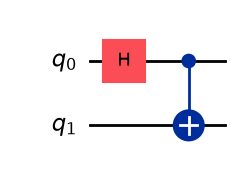

In [20]:
import numpy as np
from qiskit import QuantumCircuit, transpile

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.draw('mpl')

{'00': 513, '11': 511}


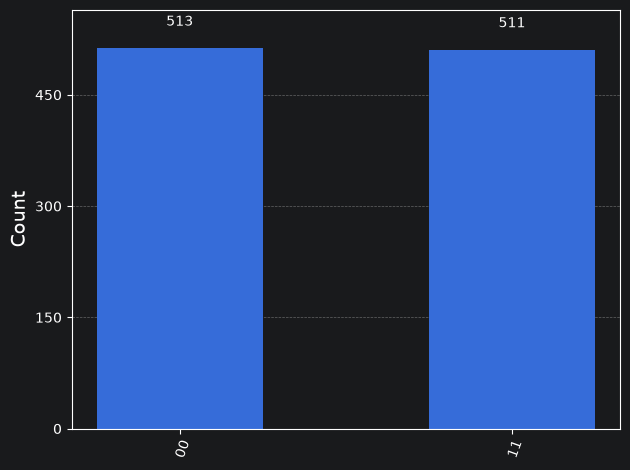

In [21]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()
print(result[0].data.meas.get_counts())

counts = result[0].data.meas.get_counts()
plot_histogram(counts)

In [22]:
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

state = Statevector.from_instruction(qc)

print(state)
print(state.data)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Counts:
{'00': 514, '11': 510}


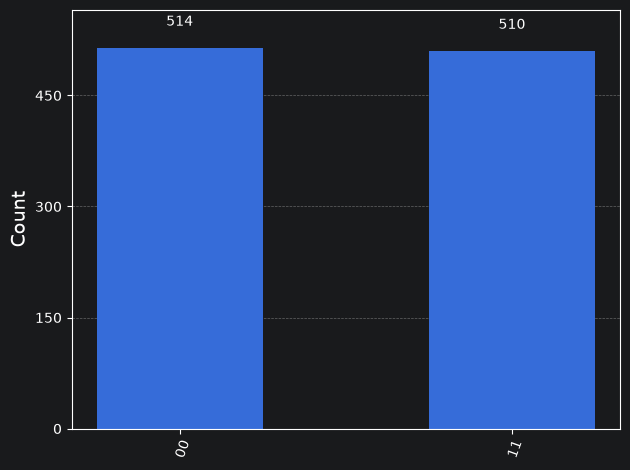

In [23]:
from qiskit_aer import AerSimulator

bell_circuit = QuantumCircuit(2)
bell_circuit.h(0)
bell_circuit.cx(0,1)

State = Statevector.from_instruction(bell_circuit)
print(State.data)
print(State)

bell_circuit.measure_all()
bell_circuit.draw('mpl')

simulator = AerSimulator()
compiled_bell_circuit = transpile(bell_circuit, simulator)

results = simulator.run(
    compiled_bell_circuit,
    shots = 1024
).result()

counts = results.get_counts()
print("\nCounts:")
print (counts)

plot_histogram(counts)

[0.65328148+0.j         0.65328148+0.j         0.        -0.27059805j
 0.        -0.27059805j]

Counts:
{'00': 439, '01': 421, '11': 83, '10': 81}


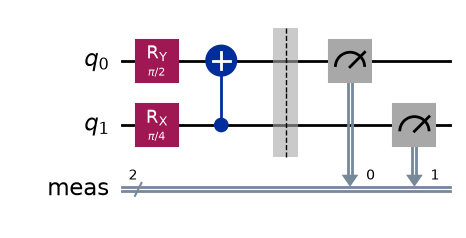

In [40]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from numpy import pi

rotation_circuit = QuantumCircuit(2)
rotation_circuit.rx(pi/4, 1)
rotation_circuit.ry(pi/2, 0)
rotation_circuit.cx(1, 0)

State = Statevector.from_instruction(rotation_circuit)
print(State.data)

rotation_circuit.measure_all()
simulator = AerSimulator()
compiled_rotation_circuit = transpile(rotation_circuit, simulator)

result = simulator.run(
    compiled_rotation_circuit,
    shots = 1024
).result()

counts = result.get_counts()
print("\nCounts:")
print(counts)
rotation_circuit.draw('mpl')

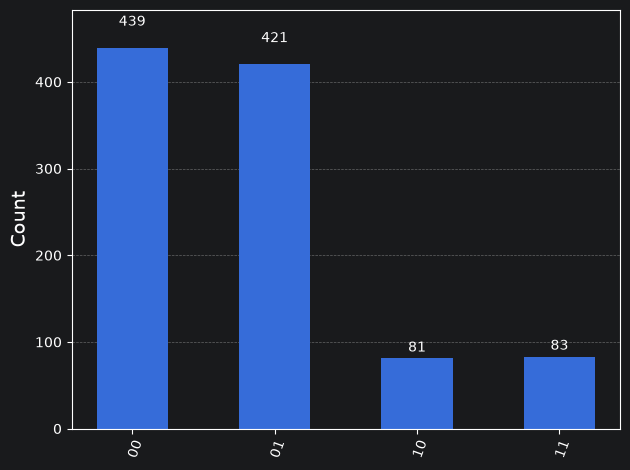

In [41]:
plot_histogram(counts)

 Compute the expectation value of $Z$ on a few simple 1‑qubit states by hand, then confirm the code matches

In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter
from qiskit.circuit import ParameterVector

from numpy import pi
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

circuit_0 = QuantumCircuit(1)

circuit_1 = QuantumCircuit(1)
circuit_1.x(0)

circuit_h = QuantumCircuit(1)
circuit_h.h(0)

z_observable = SparsePauliOp("Z")
estimator = StatevectorEstimator()

expectation_0 = estimator.run([(circuit_0, z_observable)]).result()[0].data.evs
expectation_1 = estimator.run([(circuit_1, z_observable)]).result()[0].data.evs
expectation_h = estimator.run([(circuit_h, z_observable)]).result()[0].data.evs

print(expectation_0)
print(expectation_1)
print(expectation_h)

#could also do as follows:

psi_0 = Statevector([
    1,
    0
])

psi_1 = Statevector([
    0,
    1
])

psi_h = Statevector([
    1/np.sqrt(2),
    1/np.sqrt(2)
])

print(np.real(psi_0.expectation_value(z_observable)))
print(np.real(psi_1.expectation_value(z_observable)))
print(np.real(psi_h.expectation_value(z_observable)))

1.0
-1.0
0.0
1.0
-1.0
0.0


What we find is that the expectation of a given axis observable in a given state is equal to (up to normalisation) the component of the vector in the given direction for that state's  representation on the Bloch sphere

Now experimenting with Parameter / ParameterVector

In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter
from qiskit.circuit import ParameterVector

from numpy import pi
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

theta = ParameterVector("θ", 3)
qc = QuantumCircuit(1)

qc.rx(theta[0], 0)
qc.ry(theta[1], 0)
qc.rz(theta[2], 0)

qc_1 = qc.assign_parameters([
    pi/2,
    pi/2,
    pi/2
])

qc_2 = qc.assign_parameters([
    pi/4,
    pi/2,
    pi/2
])

State_1 = Statevector.from_instruction(qc_1)
State_2 = Statevector.from_instruction(qc_2)

print(State_1.data)
print(State_2.data)


[0.70710678+0.j 0.70710678+0.j]
[0.65328148-0.27059805j 0.65328148+0.27059805j]
